# 05. XGBoost and LightGBM

Train gradient boosting models and compare them against the baseline.

In [29]:
import xgboost
import lightgbm

print("XGBoost:", xgboost.__version__)
print("LightGBM:", lightgbm.__version__)

XGBoost: 3.4.1
LightGBM: 4.7.0


In [30]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [31]:
DATA_PATH = "../data/raw/creditcard.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)

Shape: (284807, 31)


In [32]:
X = df.drop(columns=["Class"])
y = df["Class"]

In [33]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [7]:
print("Training distribution:")
print(y_train.value_counts())

print("\nFraud percentage:")
print(y_train.mean() * 100)

Training distribution:
Class
0    199020
1       344
Name: count, dtype: int64

Fraud percentage:
0.17254870488152324


In [34]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative:", negative_count)
print("Positive:", positive_count)
print("scale_pos_weight:", scale_pos_weight)

Negative: 199020
Positive: 344
scale_pos_weight: 578.546511627907


In [35]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)
eval_metric="aucpr"

In [36]:
xgb_model.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [37]:
xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [38]:
def evaluate_model(model_name, y_true, y_pred, y_prob):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )
    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )
    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )
    roc_auc = roc_auc_score(
        y_true,
        y_prob
    )
    pr_auc = average_precision_score(
        y_true,
        y_prob
    )

    print(f"\n{'=' * 50}")
    print(model_name)
    print(f"{'=' * 50}")

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1       : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(f"PR-AUC   : {pr_auc:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            zero_division=0
        )
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    }
xgb_results = evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_prob
)


XGBoost
Accuracy : 0.9995
Precision: 0.9355
Recall   : 0.7838
F1       : 0.8529
ROC-AUC  : 0.9647
PR-AUC   : 0.8358

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.94      0.78      0.85        74

    accuracy                           1.00     42722
   macro avg       0.97      0.89      0.93     42722
weighted avg       1.00      1.00      1.00     42722



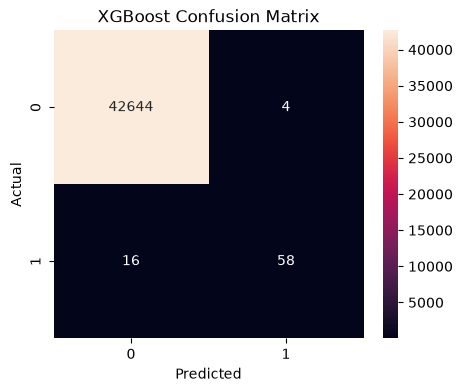

In [15]:
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [39]:
xgb_weighted = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)
xgb_weighted.fit(
    X_train,
    y_train
)
xgb_weighted_pred = xgb_weighted.predict(X_test)

xgb_weighted_prob = (
    xgb_weighted.predict_proba(X_test)[:, 1]
)
xgb_weighted_results = evaluate_model(
    "XGBoost + Class Weight",
    y_test,
    xgb_weighted_pred,
    xgb_weighted_prob
)



XGBoost + Class Weight
Accuracy : 0.9994
Precision: 0.8243
Recall   : 0.8243
F1       : 0.8243
ROC-AUC  : 0.9643
PR-AUC   : 0.8394

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.82      0.82      0.82        74

    accuracy                           1.00     42722
   macro avg       0.91      0.91      0.91     42722
weighted avg       1.00      1.00      1.00     42722



In [40]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)
lgbm_model.fit(
    X_train,
    y_train
)
lgbm_pred = lgbm_model.predict(X_test)

lgbm_prob = lgbm_model.predict_proba(X_test)[:, 1]

lgbm_results = evaluate_model(
    "LightGBM",
    y_test,
    lgbm_pred,
    lgbm_prob
)


LightGBM
Accuracy : 0.9960
Precision: 0.2316
Recall   : 0.5541
F1       : 0.3267
ROC-AUC  : 0.7355
PR-AUC   : 0.2601

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.23      0.55      0.33        74

    accuracy                           1.00     42722
   macro avg       0.62      0.78      0.66     42722
weighted avg       1.00      1.00      1.00     42722



In [41]:
lgbm_weighted = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)
lgbm_weighted.fit(
    X_train,
    y_train
)
lgbm_weighted_pred = lgbm_weighted.predict(X_test)

lgbm_weighted_prob = (
    lgbm_weighted.predict_proba(X_test)[:, 1]
)
lgbm_weighted_results = evaluate_model(
    "LightGBM + Class Weight",
    y_test,
    lgbm_weighted_pred,
    lgbm_weighted_prob
)


LightGBM + Class Weight
Accuracy : 0.9512
Precision: 0.0282
Recall   : 0.8108
F1       : 0.0544
ROC-AUC  : 0.8811
PR-AUC   : 0.0232

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     42648
           1       0.03      0.81      0.05        74

    accuracy                           0.95     42722
   macro avg       0.51      0.88      0.51     42722
weighted avg       1.00      0.95      0.97     42722



In [22]:
results = pd.DataFrame([
    xgb_results,
    xgb_weighted_results,
    lgbm_results,
    lgbm_weighted_results
])

results.sort_values(
    "PR-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
1,XGBoost + Class Weight,0.999391,0.824324,0.824324,0.824324,0.964262,0.839365
0,XGBoost,0.999532,0.935484,0.783784,0.852941,0.964739,0.835763
2,LightGBM,0.996044,0.231638,0.554054,0.326693,0.735452,0.260095
3,LightGBM + Class Weight,0.951220,0.028169,0.810811,0.054446,0.881068,0.023200


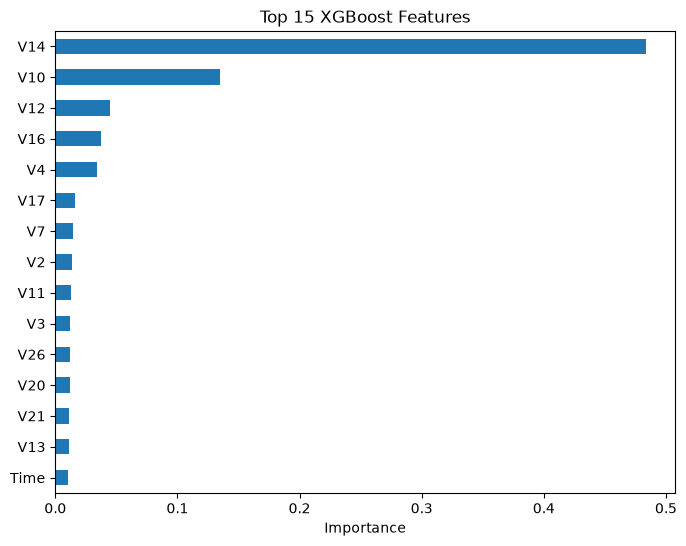

In [23]:
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)
xgb_importance.head(15)

plt.figure(figsize=(8, 6))

xgb_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 XGBoost Features")
plt.xlabel("Importance")
plt.show()

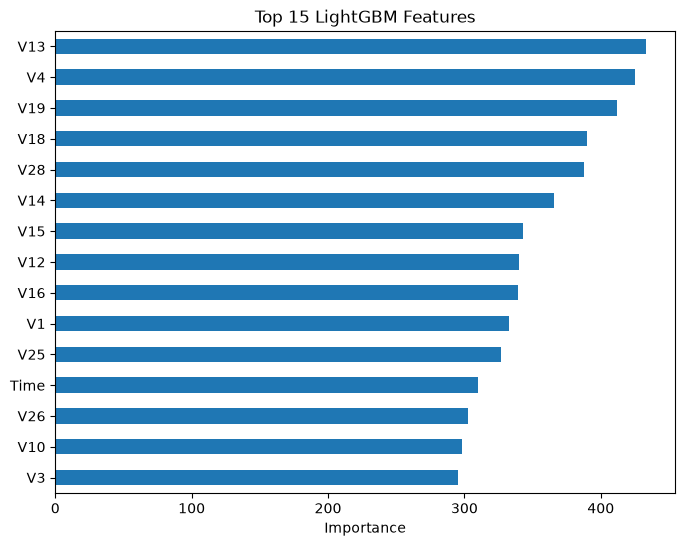

In [24]:
lgbm_importance = pd.Series(
    lgbm_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)
lgbm_importance.head(15)
plt.figure(figsize=(8, 6))

lgbm_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 LightGBM Features")
plt.xlabel("Importance")
plt.show()

In [42]:
baseline_results = pd.read_csv(
    "../data/processed/baseline_results.csv"
)

all_results = pd.concat(
    [
        baseline_results,
        pd.DataFrame([
            xgb_results,
            xgb_weighted_results,
            lgbm_results,
            lgbm_weighted_results
        ])
    ],
    ignore_index=True
)

all_results.sort_values(
    "PR-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
4,XGBoost + Class Weight,0.999391,0.824324,0.824324,0.824324,0.964262,0.839365
3,XGBoost,0.999532,0.935484,0.783784,0.852941,0.964739,0.835763
2,Random Forest,0.999602,0.952381,0.810811,0.875912,0.929969,0.826153
1,Logistic Regression,0.999274,0.921569,0.635135,0.752000,0.956459,0.749857
5,LightGBM,0.996044,0.231638,0.554054,0.326693,0.735452,0.260095
6,LightGBM + Class Weight,0.951220,0.028169,0.810811,0.054446,0.881068,0.023200
0,Dummy Classifier,0.998268,0.000000,0.000000,0.000000,0.500000,0.001732
